In [ ]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# ============================================================
!pip install transformers torch scikit-learn matplotlib seaborn

import json
import re
import os
import zipfile
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from collections import defaultdict
from tqdm.auto import tqdm  # ✅ Fix 1 — auto detects Colab
from google.colab import files


In [ ]:
from huggingface_hub import login
login()  # Enter your HuggingFace token when prompted

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# ============================================================
# CONFIG — IndicBERT
# ============================================================
# IndicBERT is based on ALBERT architecture
# It is smaller and faster than MuRIL
# We train this to COMPARE results against MuRIL
# Same pipeline, same dataset, different model = fair comparison
# ============================================================
# Option A: if you got HuggingFace access approved
MODEL_NAME = "ai4bharat/indic-bert"
MAX_LEN     = 128
BATCH_SIZE  = 16  # IndicBERT is smaller — safely use 16 on GPU
EPOCHS      = 8
LR          = 2e-5
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


Device: cuda


In [ ]:
# ============================================================
# LOAD DATA
# ============================================================
print("\n" + "=" * 60)
print("LOADING DATA")
print("=" * 60)

with open("marathi_wsd_dataset_filtered (1).json", "r", encoding="utf-8") as f:
    raw = json.load(f)

# Normalize all sense_id to string — prevents int/str key mismatch
sense_gloss = {str(item["sense_id"]): item["gloss"] for item in raw}

word_senses = defaultdict(set)
for item in raw:
    word_senses[item["target_word"]].add(str(item["sense_id"]))
word_senses = {w: list(s) for w, s in word_senses.items()}

print(f"Total rows loaded: {len(raw)}")
print(f"Total unique senses: {len(sense_gloss)}")
print(f"Total ambiguous words: {len(word_senses)}")


LOADING DATA
Total rows loaded: 50242
Total unique senses: 50
Total ambiguous words: 16


In [ ]:
# ============================================================
# DATASET CLASS
# ============================================================
# Sentence Pair Formulation:
# Input  = [Marathi Sentence] + [Gloss/Definition]
# Output = 0 (they don't match) or 1 (they match)
#
# The model acts as a judge:
# "Does this sentence use the word in the way this gloss describes?"
# ============================================================
class BinaryWSDDataset(Dataset):
    def __init__(self, items, tokenizer, max_len):
        self.items     = items
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item  = self.items[idx]

        # Get gloss for this sense — str() ensures consistent key lookup
        gloss = sense_gloss.get(str(item["sense_id"]), item["target_word"])

        # Encode (sentence, gloss) pair together
        # IndicBERT/ALBERT uses segment A and segment B
        # [CLS] sentence [SEP] gloss [SEP]
        enc = self.tokenizer(
            item["sentence"],
            gloss,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "token_type_ids": enc.get(
                "token_type_ids",
                torch.zeros(self.max_len, dtype=torch.long)
            ).squeeze(),
            "label": torch.tensor(item["label"], dtype=torch.long)
        }


In [ ]:
# ============================================================
# MODEL DEFINITION
# ============================================================
# ALBERT Encoder:
# AutoModel loads IndicBERT's pretrained ALBERT brain
# It reads the sentence+gloss pair and produces a 768-dim
# CLS token vector representing combined context of both texts
#
# Projector (Funnel):
# 768 → 512 → 256
# Compresses the representation into a focused sense space
#
# Classifier:
# 256 → 2 outputs (probability of label=0 or label=1)
# ============================================================
class WSDModel(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size  # 768 for IndicBERT
        self.projector  = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256)
        )
        self.classifier = nn.Linear(256, 2)  # binary: match or no match

    def encode(self, input_ids, attention_mask, token_type_ids):
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        cls = out.last_hidden_state[:, 0, :]  # CLS token = combined context
        return self.projector(cls)             # shape: (B, 256)

    def forward(self, input_ids, attention_mask, token_type_ids):
        emb = self.encode(input_ids, attention_mask, token_type_ids)
        return self.classifier(emb)            # shape: (B, 2)


In [ ]:
import json
from sklearn.model_selection import train_test_split # Keep import in case needed elsewhere, though not used here.
from transformers import AutoTokenizer # Import AutoTokenizer here
from torch.utils.data import Dataset, DataLoader

# ============================================================
# LOADING CUSTOM TRAIN / VAL / TEST DATASETS
# ============================================================
print("\n" + "=" * 60)
print("LOADING CUSTOM DATASETS")
print("=" * 60)

with open("train.json", "r", encoding="utf-8") as f:
    train_data = json.load(f)
with open("val.json", "r", encoding="utf-8") as f:
    val_data = json.load(f)
with open("test.json", "r", encoding="utf-8") as f:
    test_data = json.load(f)

print(f"Train rows: {len(train_data)}")
print(f"Val rows:   {len(val_data)}")
print(f"Test rows:  {len(test_data)}")

# IndicBERT uses SentencePiece tokenizer via AlbertTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = BinaryWSDDataset(train_data, tokenizer, MAX_LEN)
val_ds   = BinaryWSDDataset(val_data,   tokenizer, MAX_LEN)
test_ds  = BinaryWSDDataset(test_data,  tokenizer, MAX_LEN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

print(f"\nTrain batches: {len(train_dl)}")
print(f"Val batches:   {len(val_dl)}")
print(f"Test batches:  {len(test_dl)}")


LOADING CUSTOM DATASETS
Train rows: 35171
Val rows:   7529
Test rows:  7542


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]


Train batches: 2199
Val batches:   471
Test batches:  472


In [ ]:

# ============================================================
# LOSS FUNCTION
# ============================================================
# Weighted CrossEntropy handles label imbalance
#
# In WSD: 1 correct sense but 5-6 wrong senses per sentence
# So dataset has far more label=0 than label=1
#
# pos_weight upweights label=1 so model pays more attention
# to correct senses — forces it to not just predict 0 always
# ============================================================
avg_senses = np.mean([len(v) for v in word_senses.values()])
pos_weight = torch.tensor([1.0, float(avg_senses - 1)]).to(DEVICE)
ce_loss_fn = nn.CrossEntropyLoss(weight=pos_weight)

print(f"\nAverage senses per word: {avg_senses:.1f}")
print(f"Loss weight for label=1: {float(avg_senses - 1):.1f}")


Average senses per word: 3.1
Loss weight for label=1: 2.1


In [ ]:

# ============================================================
# TRAINING LOOP
# ============================================================
model     = WSDModel(MODEL_NAME).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, total_steps // 10),
    num_training_steps=total_steps
)

best_f1        = 0.0
train_loss_log = []
val_loss_log   = []
val_f1_log     = []

print("\n" + "=" * 60)
print("TRAINING STARTED (IndicBERT)")
print("=" * 60)

# ✅ Outer epoch bar — tracks overall progress
epoch_bar = tqdm(range(EPOCHS), desc="Overall Progress", unit="epoch")

for epoch in epoch_bar:

    # ── Train ──────────────────────────────────────────────
    model.train()
    total_train_loss = 0.0

    # ✅ leave=False — bar disappears, only summary stays
    train_bar = tqdm(
        train_dl,
        desc="Training",
        leave=False,
        unit="batch"
    )

    for batch in train_bar:
        optimizer.zero_grad()
        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE)
        )
        loss = ce_loss_fn(logits, batch["label"].to(DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = total_train_loss / len(train_dl)
    train_loss_log.append(avg_train_loss)

    # ── Validate ───────────────────────────────────────────
    model.eval()
    total_val_loss = 0.0
    all_preds      = []
    all_labels     = []

    val_bar = tqdm(
        val_dl,
        desc="Validating",
        leave=False,
        unit="batch"
    )

    with torch.no_grad():
        for batch in val_bar:
            logits = model(
                batch["input_ids"].to(DEVICE),
                batch["attention_mask"].to(DEVICE),
                batch["token_type_ids"].to(DEVICE)
            )
            val_loss = ce_loss_fn(logits, batch["label"].to(DEVICE))
            total_val_loss += val_loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["label"].cpu().numpy())
            val_bar.set_postfix(loss=f"{val_loss.item():.4f}")

    avg_val_loss = total_val_loss / len(val_dl)
    val_loss_log.append(avg_val_loss)

    f1 = f1_score(all_labels, all_preds, average="macro")
    val_f1_log.append(f1)

    # Update outer bar with metrics
    epoch_bar.set_postfix(
        train_loss=f"{avg_train_loss:.4f}",
        val_loss=f"{avg_val_loss:.4f}",
        f1=f"{f1:.4f}"
    )

    # Clean summary per epoch
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"  Train Loss : {avg_train_loss:.4f}")
    print(f"  Val Loss   : {avg_val_loss:.4f}")
    print(f"  Val F1     : {f1:.4f}")

    # ✅ Fix 4 — Overfitting warning
    if len(train_loss_log) > 1:
        if val_loss_log[-1] > val_loss_log[-2] and train_loss_log[-1] < train_loss_log[-2]:
            print(f"  ⚠ Warning: Val loss increasing while Train loss decreasing — possible overfitting")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_indicbert_wsd.pt")
        print(f"  ✅ Saved best IndicBERT model (F1={f1:.4f})")

print(f"\nBest Val Macro-F1: {best_f1:.4f}")



pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: ai4bharat/indic-bert
Key                              | Status     |  | 
---------------------------------+------------+--+-
predictions.decoder.bias         | UNEXPECTED |  | 
predictions.LayerNorm.bias       | UNEXPECTED |  | 
sop_classifier.classifier.weight | UNEXPECTED |  | 
predictions.LayerNorm.weight     | UNEXPECTED |  | 
predictions.bias                 | UNEXPECTED |  | 
predictions.dense.bias           | UNEXPECTED |  | 
predictions.dense.weight         | UNEXPECTED |  | 
sop_classifier.classifier.bias   | UNEXPECTED |  | 
predictions.decoder.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



TRAINING STARTED (IndicBERT)


Overall Progress:   0%|          | 0/8 [00:00<?, ?epoch/s]

...

Validating:   0%|          | 0/471 [00:00<?, ?batch/s]


Epoch 7/8
  Train Loss : 0.3991
  Val Loss   : 0.4028
  Val F1     : 0.8012
  ⚠ Warning: Val loss increasing while Train loss decreasing — possible overfitting


Training:   0%|          | 0/2199 [00:00<?, ?batch/s]

Validating:   0%|          | 0/471 [00:00<?, ?batch/s]


Epoch 8/8
  Train Loss : 0.3856
  Val Loss   : 0.4026
  Val F1     : 0.8035

Best Val Macro-F1: 0.8083


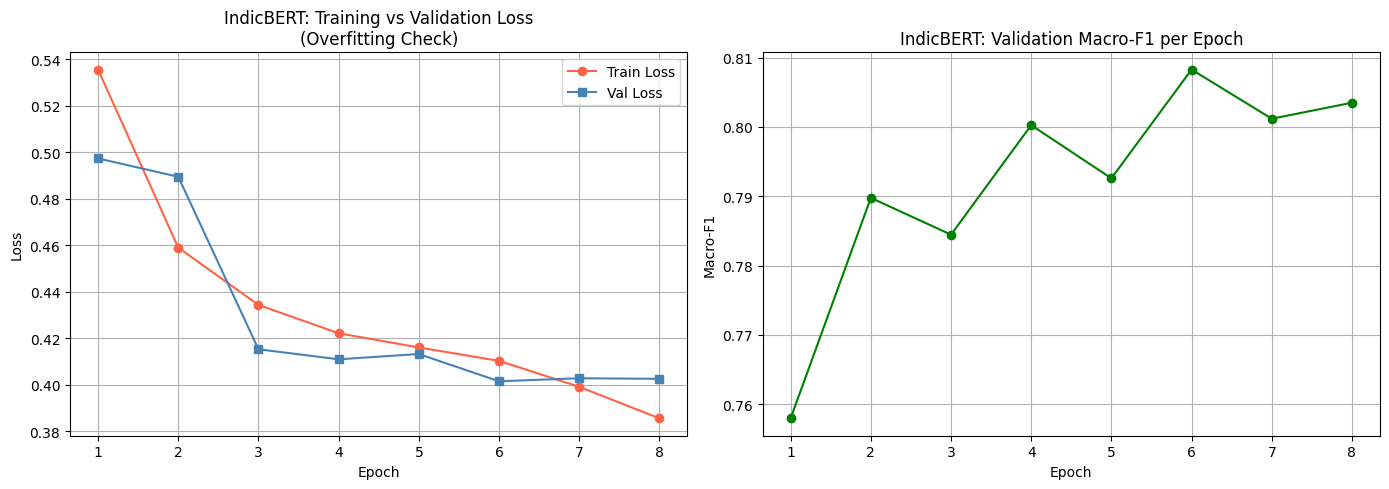

Training curves saved


In [ ]:

# ============================================================
# PLOT TRAINING VS VALIDATION LOSS
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS+1), train_loss_log, label='Train Loss', marker='o', color='tomato')
ax1.plot(range(1, EPOCHS+1), val_loss_log,   label='Val Loss',   marker='s', color='steelblue')
ax1.set_title("IndicBERT: Training vs Validation Loss\n(Overfitting Check)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, EPOCHS+1), val_f1_log, marker='o', color='green')
ax2.set_title("IndicBERT: Validation Macro-F1 per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro-F1")
ax2.grid(True)

plt.tight_layout()
plt.savefig("indicbert_training_curves.png", dpi=150)
plt.show()
print("Training curves saved")



In [ ]:

# ============================================================
# FINAL EVALUATION ON UNSEEN TEST SET
# ============================================================
# Final Exam — model never saw this data during training
# Load BEST checkpoint not last epoch
# ============================================================
print("\n" + "=" * 60)
print("FINAL EVALUATION ON UNSEEN TEST SET")
print("=" * 60)

best_ckpt = torch.load("best_indicbert_wsd.pt", map_location=DEVICE)
model.load_state_dict(best_ckpt)
model.eval()

all_test_preds  = []
all_test_labels = []

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Testing", leave=False):
        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE)
        )
        preds = torch.argmax(logits, dim=1)
        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(batch["label"].cpu().numpy())

test_acc = accuracy_score(all_test_labels, all_test_preds)
test_f1  = f1_score(all_test_labels, all_test_preds, average="macro")

print(f"\nIndicBERT Test Accuracy : {test_acc*100:.2f}%")
print(f"IndicBERT Test Macro-F1 : {test_f1:.4f}")
print("\nClassification Report:")
print(classification_report(
    all_test_labels, all_test_preds,
    target_names=["Wrong Sense", "Correct Sense"]
))



FINAL EVALUATION ON UNSEEN TEST SET


Testing:   0%|          | 0/472 [00:00<?, ?it/s]


IndicBERT Test Accuracy : 83.29%
IndicBERT Test Macro-F1 : 0.8050

Classification Report:
               precision    recall  f1-score   support

  Wrong Sense       0.86      0.90      0.88      5078
Correct Sense       0.77      0.70      0.73      2464

     accuracy                           0.83      7542
    macro avg       0.81      0.80      0.81      7542
 weighted avg       0.83      0.83      0.83      7542



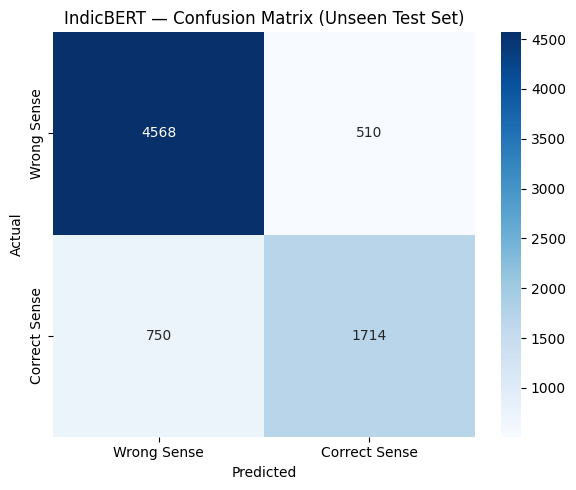

Confusion matrix saved


In [ ]:

# ============================================================
# CONFUSION MATRIX — ✅ Fix 3 — was missing
# ============================================================
cm = confusion_matrix(all_test_labels, all_test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Wrong Sense", "Correct Sense"],
    yticklabels=["Wrong Sense", "Correct Sense"]
)
plt.title("IndicBERT — Confusion Matrix (Unseen Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("indicbert_confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved")

In [ ]:
# ============================================================
# PER-WORD ACCURACY ON TEST SET — ✅ Fix 2 — was missing
# ============================================================
print("\n" + "=" * 60)
print("PER-WORD ACCURACY ON TEST SET")
print("=" * 60)

per_word_test = defaultdict(lambda: {"correct": 0, "total": 0})

model.eval()
test_item_idx = 0

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Per-word evaluation", leave=False):
        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE)
        )
        preds  = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["label"].cpu().numpy()

        batch_size = len(labels)
        for i in range(batch_size):
            item = test_data[test_item_idx + i]
            word = item["target_word"]
            per_word_test[word]["total"] += 1
            if preds[i] == labels[i]:
                per_word_test[word]["correct"] += 1
        test_item_idx += batch_size

print(f"\n{'Word':<15} {'Accuracy Bar':<25} {'Score':<8} {'Correct/Total'}")
print("-" * 60)
for word, res in sorted(per_word_test.items()):
    acc = res["correct"] / res["total"] if res["total"] > 0 else 0
    bar = "█" * int(acc * 20) + "░" * (20 - int(acc * 20))
    print(f"  {word:<13} [{bar}] {acc:.3f}   ({res['correct']}/{res['total']})")




PER-WORD ACCURACY ON TEST SET


Per-word evaluation:   0%|          | 0/472 [00:00<?, ?it/s]


Word            Accuracy Bar              Score    Correct/Total
------------------------------------------------------------
  अंक           [█████████████░░░░░░░] 0.659   (87/132)
  अर्थ          [████████████████░░░░] 0.819   (199/243)
  गुण           [████████████░░░░░░░░] 0.639   (94/147)
  डोळा          [████████████████░░░░] 0.800   (300/375)
  देणे          [█████████████████░░░] 0.885   (1412/1596)
  नाव           [█████████████░░░░░░░] 0.667   (182/273)
  पाठ           [██████████████░░░░░░] 0.739   (153/207)
  बरोबर         [█████████████░░░░░░░] 0.667   (96/144)
  भाव           [████████████░░░░░░░░] 0.627   (128/204)
  मंद           [█████████████░░░░░░░] 0.651   (127/195)
  मार्ग         [█████████████░░░░░░░] 0.663   (161/243)
  योग           [█████████████░░░░░░░] 0.675   (162/240)
  वर            [███████████████████░] 0.959   (2652/2766)
  वाट           [██████████████░░░░░░] 0.704   (247/351)
  वाटणे         [████████████░░░░░░░░] 0.603   (85/141)
  वार           [█

In [ ]:
# ============================================================
# PER-WORD PRECISION, RECALL, F1 — IndicBERT
# ============================================================
from sklearn.metrics import precision_score, recall_score, f1_score
from collections import defaultdict

print("\n" + "=" * 60)
print("PER-WORD PRECISION / RECALL / F1 ON TEST SET (IndicBERT)")
print("=" * 60)

# ✅ Load best IndicBERT checkpoint
best_ckpt = torch.load("best_indicbert_wsd.pt", map_location=DEVICE)
model.load_state_dict(best_ckpt)
model.eval()

per_word_labels = defaultdict(list)
per_word_preds  = defaultdict(list)

test_item_idx = 0

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Evaluating", leave=False):
        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE)
        )
        preds  = torch.argmax(logits, dim=1).cpu().numpy()
        labels = batch["label"].cpu().numpy()

        batch_size = len(labels)
        for i in range(batch_size):
            word = test_data[test_item_idx + i]["target_word"]
            per_word_labels[word].append(int(labels[i]))
            per_word_preds[word].append(int(preds[i]))
        test_item_idx += batch_size

# ── Print table ───────────────────────────────────────────
print(f"\n{'Word':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 58)

all_words_labels = []
all_words_preds  = []

for word in sorted(per_word_labels.keys()):
    y_true = per_word_labels[word]
    y_pred = per_word_preds[word]

    p  = precision_score(y_true, y_pred, average="macro", zero_division=0)
    r  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    support = len(y_true)

    print(f"  {word:<13} {p:>10.4f} {r:>10.4f} {f1:>10.4f} {support:>10}")

    all_words_labels.extend(y_true)
    all_words_preds.extend(y_pred)

# ── Overall row ───────────────────────────────────────────
print("-" * 58)
overall_p  = precision_score(all_words_labels, all_words_preds, average="macro", zero_division=0)
overall_r  = recall_score(all_words_labels, all_words_preds, average="macro", zero_division=0)
overall_f1 = f1_score(all_words_labels, all_words_preds, average="macro", zero_division=0)

print(f"  {'OVERALL':<13} {overall_p:>10.4f} {overall_r:>10.4f} {overall_f1:>10.4f} {len(all_words_labels):>10}")


PER-WORD PRECISION / RECALL / F1 ON TEST SET (IndicBERT)


Evaluating:   0%|          | 0/472 [00:00<?, ?it/s]


Word             Precision     Recall         F1    Support
----------------------------------------------------------
  अंक               0.5000     0.5000     0.4176        132
  अर्थ              0.8473     0.7438     0.7667        243
  गुण               0.5317     0.5153     0.4877        147
  डोळा              0.4000     0.5000     0.4444        375
  देणे              0.8701     0.8708     0.8704       1596
  नाव               0.6257     0.6264     0.6260        273
  पाठ               0.7058     0.6848     0.6920        207
  बरोबर             0.3333     0.5000     0.4000        144
  भाव               0.5809     0.5809     0.5809        204
  मंद               0.6077     0.6077     0.6077        195
  मार्ग             0.6204     0.6204     0.6204        243
  योग               0.6303     0.6250     0.6271        240
  वर                0.9536     0.9536     0.9536       2766
  वाट               0.6667     0.6667     0.6667        351
  वाटणे             0.5532     0.5532   

In [ ]:

# ============================================================
# EXPORT DEPLOYMENT PACKAGE
# ============================================================
print("\n" + "=" * 60)
print("EXPORTING DEPLOYMENT PACKAGE")
print("=" * 60)

EXPORT_DIR = "indicbert_wsd_deployment"
os.makedirs(EXPORT_DIR, exist_ok=True)

tokenizer.save_pretrained(f"{EXPORT_DIR}/tokenizer")
print("✅ Tokenizer saved")

torch.save(model.state_dict(), f"{EXPORT_DIR}/model_weights.pt")
print("✅ Model weights saved")

model.encoder.config.save_pretrained(f"{EXPORT_DIR}/encoder_config")
print("✅ Encoder config saved")

metadata = {
    "model_name":     MODEL_NAME,
    "max_len":        MAX_LEN,
    "sense_gloss":    sense_gloss,
    "word_to_senses": dict(word_senses),
    "test_accuracy":  round(test_acc * 100, 2),
    "test_macro_f1":  round(test_f1, 4)
}
with open(f"{EXPORT_DIR}/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("✅ Metadata saved")

import shutil
for plot_file in ["indicbert_training_curves.png", "indicbert_confusion_matrix.png"]:
    if os.path.exists(plot_file):
        shutil.copy(plot_file, f"{EXPORT_DIR}/{plot_file}")
print("✅ Plots saved")

zip_path = "indicbert_wsd_deployment.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, file_list in os.walk(EXPORT_DIR):
        for file in file_list:
            filepath = os.path.join(root, file)
            zf.write(filepath, os.path.relpath(filepath))

print(f"\n✅ Zipped: {zip_path}")
files.download(zip_path)


EXPORTING DEPLOYMENT PACKAGE
✅ Tokenizer saved
✅ Model weights saved
✅ Encoder config saved
✅ Metadata saved
✅ Plots saved

✅ Zipped: indicbert_wsd_deployment.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("best_indicbert_wsd.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import json
from google.colab import files

# Save train split
with open("train_data.json", "w", encoding="utf-8") as f:
    json.dump(train_data, f, ensure_ascii=False, indent=2)

# Save val split
with open("val_data.json", "w", encoding="utf-8") as f:
    json.dump(val_data, f, ensure_ascii=False, indent=2)

# Save test split
with open("test_data.json", "w", encoding="utf-8") as f:
    json.dump(test_data, f, ensure_ascii=False, indent=2)

print(f"✅ train_data.json — {len(train_data)} rows")
print(f"✅ val_data.json   — {len(val_data)} rows")
print(f"✅ test_data.json  — {len(test_data)} rows")

# Download all three
files.download("train_data.json")
files.download("val_data.json")
files.download("test_data.json")

✅ train_data.json — 35027 rows
✅ val_data.json   — 7722 rows
✅ test_data.json  — 7493 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("indicbert_training_curves.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>